          LAB 07: ADVANCED STATISTICAL ANALYSIS REPORT
Metric                         | Theoretical Value  | Sample Value
-----------------------------------------------------------------
Sample Size (N)                | 200                | 200       
Mean (μ) of Blood Pressure     | 80.0000 mmHg       | 79.1846
Std Deviation (σ)              | 20.0000 mmHg       | 18.5735


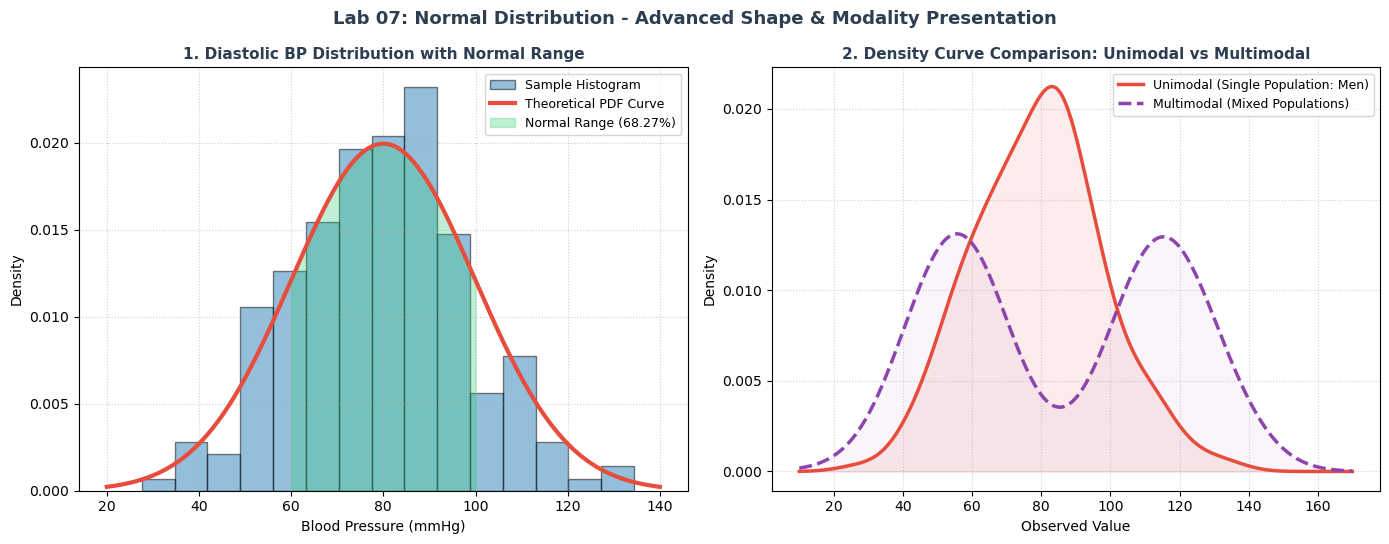

In [7]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# জেনারেট করা ডেটা ফিক্স রাখার জন্য বীজ
np.random.seed(42)

# --- ১. রক্তচাপের ডেটা জেনারেশন (Size = 200) ---
bp_data = np.random.normal(loc=80, scale=20, size=200)

# --- ২. মাল্টিমোডাল কার্ভের জন্য মিশ্র ডেটা তৈরি ---
group_a = np.random.normal(loc=55, scale=10, size=100)
group_b = np.random.normal(loc=115, scale=12, size=100)
multimodal_data = np.concatenate([group_a, group_b])

# --- ৩. পরিসংখ্যানগত হিসাব (Descriptive Statistics) ---
calculated_mean = np.mean(bp_data)
calculated_std = np.standard_deviation = np.std(bp_data)

print("=" * 65)
print("          LAB 07: ADVANCED STATISTICAL ANALYSIS REPORT")
print("=" * 65)
print(f"{'Metric':<30} | {'Theoretical Value':<18} | {'Sample Value':<10}")
print("-" * 65)
print(f"{'Sample Size (N)':<30} | {'200':<18} | {len(bp_data):<10}")
print(f"{'Mean (μ) of Blood Pressure':<30} | {'80.0000 mmHg':<18} | {calculated_mean:.4f}")
print(f"{'Std Deviation (σ)':<30} | {'20.0000 mmHg':<18} | {calculated_std:.4f}")
print("=" * 65)

# --- ৪. আল্ট্রা-প্রফেশনাল গ্রাফিক্যাল ডিসপ্লে ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# (ক) গ্রাফ ১: রক্তচাপের ডিস্ট্রিবিউশন + Empirical Rule (68%) Shading
count, bins, patches = ax1.hist(bp_data, bins=15, density=True, alpha=0.5, color='#2980b9', edgecolor='black', label='Sample Histogram')
x_axis = np.linspace(20, 140, 500)
y_pdf = stats.norm.pdf(x_axis, loc=80, scale=20)
ax1.plot(x_axis, y_pdf, color='#e74c3c', linewidth=3, label='Theoretical PDF Curve')

# ম্যাজিক টাচ: ৬০ থেকে ১০০ mmHg (Mean ± 1 SD) এলাকাটি হালকা সবুজ রঙে হাইলাইট করা হলো
x_shade = np.linspace(60, 100, 200)
ax1.fill_between(x_shade, stats.norm.pdf(x_shade, loc=80, scale=20), color='#2ecc71', alpha=0.3, label='Normal Range (68.27%)')

ax1.set_title("1. Diastolic BP Distribution with Normal Range", fontsize=11, fontweight='bold', color='#2c3e50')
ax1.set_xlabel("Blood Pressure (mmHg)", fontsize=10)
ax1.set_ylabel("Density", fontsize=10)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, linestyle=":", alpha=0.6)

# (খ) গ্রাফ ২: ইউনিমোডাল বনাম মাল্টিমোডাল এর প্রফেশনাল রূপ
x_range = np.linspace(10, 170, 300)
density_uni = stats.gaussian_kde(bp_data)
density_multi = stats.gaussian_kde(multimodal_data)

ax2.plot(x_range, density_uni(x_range), color='#e74c3c', linewidth=2.5, label='Unimodal (Single Population: Men)')
ax2.fill_between(x_range, density_uni(x_range), color='#e74c3c', alpha=0.1)

ax2.plot(x_range, density_multi(x_range), color='#8e44ad', linewidth=2.5, linestyle='--', label='Multimodal (Mixed Populations)')
ax2.fill_between(x_range, density_multi(x_range), color='#8e44ad', alpha=0.05)

ax2.set_title("2. Density Curve Comparison: Unimodal vs Multimodal", fontsize=11, fontweight='bold', color='#2c3e50')
ax2.set_xlabel("Observed Value", fontsize=10)
ax2.set_ylabel("Density", fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Lab 07: Normal Distribution - Advanced Shape & Modality Presentation", fontsize=13, fontweight='bold', color='#2c3e50', y=0.98)
plt.tight_layout()
plt.show()